In [9]:
from keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPool2D
from sklearn.metrics import classification_report
%matplotlib inline

In [5]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
# loading the data

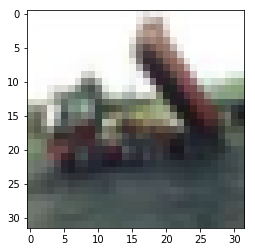

In [6]:
plt.imshow(X_train[2])

In [7]:
X_train = X_train.astype(np.float32) / 255 # we covert tbe image just we did in MNISt
X_test = X_test.astype(np.float32)  / 255

In [10]:
y_cat_train = to_categorical(y_train, 10)
y_cat_test = to_categorical(y_test, 10)

In [14]:
model = Sequential() # adding the model 

# first input layer
model.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(32,32,3), activation='relu'))

# first pooling layer
model.add(MaxPool2D(pool_size=(2,2)))

# second input layer
model.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(32,32,3), activation='relu'))

# second pooling layer
model.add(MaxPool2D(pool_size=(2,2)))

# flattening the images for dense layer
model.add(Flatten())

# first dense layer
model.add(Dense(256, activation='relu'))

# final dense layer
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics= ['accuracy'])


In [ ]:
model.fit(X_train, y_cat_train, epochs=10, verbose=1)

1563/1563 [==============================] - 36s 23ms/step - loss: 0.8714 - accuracy: 0.6974


In [17]:
model.evaluate(X_test, y_cat_test)

313/313 [==============================] - 3s 9ms/step - loss: 1.0319 - accuracy: 0.6495


[1.0318758487701416, 0.6495000123977661]

In [19]:
predicts = model.predict(X_test)

In [20]:
print(classification_report(y_test, predicts))

ValueError: Mix type of y not allowed, got types {'multiclass', 'continuous-multioutput'}

In [21]:
predicts.shape

(10000, 10)